In [2]:
#!pip install "transformers==4.44.0"

In [3]:
!pip show tensorflow
!pip show transformers

Name: tensorflow
Version: 2.20.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, libclang, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, tensorboard, termcolor, typing_extensions, wrapt
Required-by: dopamine_rl, tensorflow-text, tf_keras, ydf_tf
Name: transformers
Version: 4.44.0
Summary: State-of-the-art Machine Learning for JAX, PyTorch and TensorFlow
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: /usr/local/lib/python3.12/dist-packages
Re

In [4]:
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [5]:
import json

with open("train.jsonl", "r", encoding="utf-8") as f:
    train_data = [json.loads(line) for line in f]

with open("test.jsonl", "r", encoding="utf-8") as f:
    test_data = [json.loads(line) for line in f]

train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)


In [6]:
def label_map(label):
    if label == "AI":
        return 1
    else:
        return 0

train_df["label"] = train_df["label"].apply(label_map)
test_df["label"] = test_df["label"].apply(label_map)

train_texts = train_df["text"].tolist()
train_labels = train_df["label"].tolist()

val_texts = test_df["text"].tolist()
val_labels = test_df["label"].tolist()

print("Train label distribution:")
print(train_df["label"].value_counts())
print("\nTest label distribution:")
print(test_df["label"].value_counts())


Train label distribution:
label
0    2386
1    2386
Name: count, dtype: int64

Test label distribution:
label
0    674
1    674
Name: count, dtype: int64


In [7]:
print("Train shape:", train_df.shape)
print(train_df.head())

print("Test shape:", test_df.shape)
print(test_df.head())


Train shape: (4772, 7)
                                                text  label  \
0  engineering (an existing interface is user req...      0   
1  Ingineria software permite adaptarea unei inte...      1   
2  Dezvoltarea interfețelor utilizator prin abord...      1   
3  duction, automated or not. formation, software...      0   
4  one interactive application to another. In thi...      0   

             AI_used  chunk_no  source  \
0               none         1       1   
1  claude-sonnet-4-5         1       1   
2  claude-sonnet-4-5         2       1   
3               none         2       1   
4               none         3       1   

                                          source_url  year_of_publication  
0  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...                 2008  
1  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...                 2008  
2  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...                 2008  
3  https://rochi.utcluj.ro/rrioc/articole

In [8]:
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("FacebookAI/xlm-roberta-base")

max_length = 512

train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length = max_length,
    return_tensors='tf'
)

val_encodings = tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length = max_length,
    return_tensors='tf'
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [9]:
print("Num examples in encodings:", train_encodings["input_ids"].shape[0])
print("Num labels:", len(train_labels))

Num examples in encodings: 4772
Num labels: 4772


In [10]:
train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    train_labels
))

val_dataset = tf.data.Dataset.from_tensor_slices((
    dict(val_encodings),
    val_labels
))

In [11]:
import tensorflow as tf
from transformers import TFAutoModelForSequenceClassification

model = TFAutoModelForSequenceClassification.from_pretrained(
    'FacebookAI/xlm-roberta-base',
    num_labels=2,
)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
    run_eagerly=True
)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFXLMRobertaForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFXLMRobertaForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [12]:
train_dataset = train_dataset.shuffle(100).batch(16)
val_dataset = val_dataset.batch(16)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=3
)

Epoch 1/3


299/299 [==============================] - 306s 934ms/step - loss: 0.2225 - accuracy: 0.9189 - val_loss: 0.0825 - val_accuracy: 0.9674
Epoch 2/3
299/299 [==============================] - 251s 841ms/step - loss: 0.0555 - accuracy: 0.9830 - val_loss: 0.0397 - val_accuracy: 0.9896
Epoch 3/3
299/299 [==============================] - 241s 807ms/step - loss: 0.0373 - accuracy: 0.9893 - val_loss: 0.0308 - val_accuracy: 0.9896


In [13]:
loss, accuracy = model.evaluate(val_dataset)
print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

85/85 [==============================] - 18s 216ms/step - loss: 0.0308 - accuracy: 0.9896
Validation Loss: 0.030773287639021873
Validation Accuracy: 0.9896142482757568


In [14]:
import numpy as np

y_true = []
y_pred = []

for batch_features, batch_labels in val_dataset:
    logits = model(batch_features, training=False).logits
    predictions = tf.math.argmax(logits, axis=1)

    y_pred.extend(predictions.numpy())
    y_true.extend(batch_labels.numpy())

              precision    recall  f1-score   support

       Human     0.9985    0.9807    0.9895       674
          AI     0.9810    0.9985    0.9897       674

    accuracy                         0.9896      1348
   macro avg     0.9898    0.9896    0.9896      1348
weighted avg     0.9898    0.9896    0.9896      1348



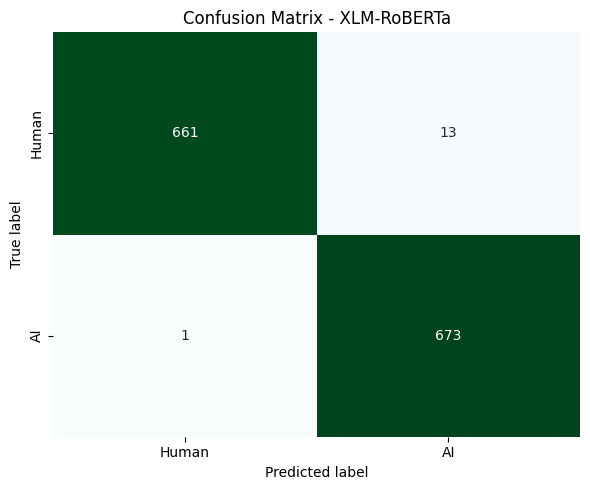

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

class_names = ["Human", "AI"]

print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

conf_mat = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_mat,
    annot=True,
    fmt="d",
    cmap="BuGn",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=False
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - XLM-RoBERTa")
plt.tight_layout()
plt.show()

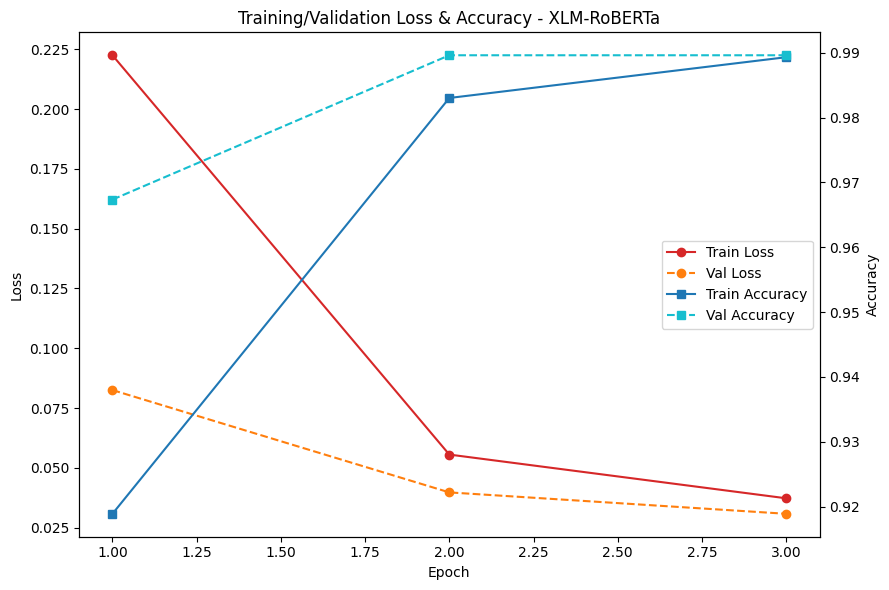

In [16]:
import matplotlib.pyplot as plt

hist = history.history
epochs_range = range(1, len(hist["loss"]) + 1)

fig, ax1 = plt.subplots(figsize=(9, 6))

#loss
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
line1 = ax1.plot(epochs_range, hist["loss"], color="tab:red", marker="o", label="Train Loss")
line2 = ax1.plot(epochs_range, hist["val_loss"], color="tab:orange", marker="o", linestyle="--", label="Val Loss")
ax1.tick_params(axis="y")

#accuracy
ax2 = ax1.twinx()
ax2.set_ylabel("Accuracy")
line3 = ax2.plot(epochs_range, hist["accuracy"], color="tab:blue", marker="s", label="Train Accuracy")
line4 = ax2.plot(epochs_range, hist["val_accuracy"], color="tab:cyan", marker="s", linestyle="--", label="Val Accuracy")
ax2.tick_params(axis="y")

#legend
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="center right")

plt.title("Training/Validation Loss & Accuracy - XLM-RoBERTa")
fig.tight_layout()
plt.show()

In [17]:
examples = {
    ("correct", 0): [],
    ("correct", 1): [],
    ("incorrect", 0): [],
    ("incorrect", 1): [],
}

max_per_group = 3

for i in range(len(y_true)):
    true_label = y_true[i]
    pred_label = y_pred[i]
    is_correct = (true_label == pred_label)
    key = ("correct" if is_correct else "incorrect", true_label)

    if len(examples[key]) < max_per_group:
        examples[key].append(val_texts[i])

    if all(len(v) >= max_per_group for v in examples.values()):
        break

class_names = {0: "Human", 1: "AI"}

for (status, label), texts in examples.items():
    print(f"\n{'='*60}")
    print(f"{status.upper()} - class: {class_names[label]} ({len(texts)} examples)")
    print('='*60)
    for j, text in enumerate(texts, 1):
        print(f"\n[{j}] {text[:300]}{'...' if len(text) > 300 else ''}")


CORRECT - class: Human (3 examples)

[1] aplicațiilor distribuite precum Remote Procedure Calls Cuvinte cheie (RPC), Distributed Component Object Model (DCOM), Arhitectură multinivel, componente software, flux Common Object Request Broker Architecture (CORBA), multimedia, sistem multimedia distribuit JavaRMI (Remote Method Invocation) nu a...

[2] ale video și audio și a celor independente de timp: echipamentelor periferice și ale rețelelor de imagini statice, informații în format text, animații; comunicație, • Asigură performanțe bune pentru realizarea • să permită controlul total al datelor multimedia, în prelucrărilor în timp real, ceea ce...

[3] date în vederea extragerii și în baza de date multimedia. utilizării datelor multimedia stocate. Interogarea bazei • Componenta pentru adnotarea fișierului video de date multimedia se realizează în două moduri: afișează succesiunea de cadre a fișierului video, folosind pentru căutare informații de t...

CORRECT - class: AI (3 examples)

[

In [18]:
#model download

model.save_pretrained("./document-xlmr-model")
tokenizer.save_pretrained("./document-xlmr-model")

from google.colab import files
import shutil
shutil.make_archive("document-xlmr-model", "zip", "./document-xlmr-model")
files.download("document-xlmr-model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>